---
title: Deep Neural Networks

---

::: {.callout-tip}
## Slides
[Slides](https://docs.google.com/presentation/d/1Bk61VR7h6q_lAa02fRCy464I2wyXLJg8nJQ1qKdyFLA/edit?slide=id.g32ea142b459_0_0#slide=id.g32ea142b459_0_0)
::: 


<a href="https://colab.research.google.com/github/fahadsultan/csc372/blob/main/dnn.ipynb" target="_blank" align="right">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>


Previously, we saw that as the number of hidden units increases in shallow neural networks, their descriptive power also improves. 

Indeed, with enough hidden units, shallow networks can describe arbitrarily complex functions in high dimensions. 

However, it turns out that for some functions, the required number of hidden units is impractically large. 

<span style="color: #a183de;">Deep networks, networks with more than one hidden layer, can produce many more linear regions than shallow networks for the same number of parameters. </span>

Hence, even though theoretically Shallow and Deep neural networks might be equivalent in terms of the functions they can describe, <span style="color: #a183de;">from a practical standpoint, deep networks can be used to describe a broader family of functions</span>.

It is also important to be mindful of the fact that with ReLU activation functions, both shallow and deep networks describe piecewise linear mappings from input to output.

## Concatenating shallow networks

Consider composing two shallow networks so the output of the first becomes the input of the second. 

Consider two shallow networks with three hidden units each . The first network takes
an input x and returns output y and is defined by:

\begin{eqnarray}\label{eq:dnn_comp_in}
 h_{1} &=& \mbox{a}[\theta_{10} + \theta_{11}x] \nonumber \\
 h_{2} &=& \mbox{a}[\theta_{20} + \theta_{21}x] \nonumber \\
 h_{3} &=& \mbox{a}[\theta_{30} + \theta_{31}x],
 \end{eqnarray}

\begin{eqnarray}\label{eq:dnn_comp}
 y = \phi_{0}+\phi_{1}h_{1}+\phi_{2}h_{2}+\phi_{3}h_{3}.
 \end{eqnarray}

<span style="color: #a183de;">The second network takes $y$ as input and returns $y'$</span> and is defined by:

\begin{eqnarray}\label{eq:dnn_comp_2}
 h'_{1} &=& \mbox{a}[\theta'_{10} + \theta'_{11}y] \nonumber \\
 h'_{2} &=& \mbox{a}[\theta'_{20} + \theta'_{21}y] \nonumber \\
 h'_{3} &=& \mbox{a}[\theta'_{30} + \theta'_{31}y],
 \end{eqnarray}

\begin{eqnarray} \label{eq:dnn_comp_out}
 y' = \phi'_{0}+\phi'_{1}h'_{1}+\phi'_{2}h'_{2}+\phi'_{3}h'_{3}.
 \end{eqnarray}

With ReLU activations, this model also describes a family of piecewise linear functions.

However, the number of linear regions is potentially greater than for a shallow network
with six hidden units. 

To see this, consider choosing the first network to produce three alternating regions of positive and negative slope. 

This means that three different ranges of $x$ are mapped to the same output range $y \in [−1,1]$, and the subsequent mapping from this range of $y$ to $\hat{y}$ is applied three times. 

<span style="color: #a183de;">The overall effect is that the function defined by the second network is duplicated three times to create nine linear regions</span>. 

The same principle applies in higher dimensions.

A different way to think about composing networks is that <span style="color: #a183de;">the first network “folds” the input space $x$ back onto itself so that multiple inputs generate the same output. Then the second network applies a function, which is replicated at all points that were folded on top of one another</span>.


<img src="assets/Chap04/DeepConcat.svg" style="filter: invert(1);" width="100%">

a) The output y of the first network constitutes the input to the second network. 

b) The first network maps inputs $x \in [−1, 1]$ to outputs $y \in [−1, 1]$ using a function comprising three linear regions that are chosen so that they alternate the sign of their slope (fourth linear region is outside range of graph). 

    Multiple inputs x (gray circles) now map to the same output y (red circle). 

c) The second network defines a function comprising three linear regions that takes $y$ and returns $y'$ (i.e., the red circle is mapped to the blue circle). 

d) The combined effect of these two functions when composed is that 

(i) three different inputs $x$ are mapped to any given value of $y$ by the first network and 
(ii) are processed in the same way by the second network; the result is that the <span style="color: #a183de;">function defined by the second network in panel (c) is duplicated three times, variously flipped and rescaled according to
the slope of the regions of panel (b)<span style="color: #a183de;">. 


<img src="assets/Chap04/DeepFold.svg" style="filter: invert(1);" width="100%">

Deep networks as folding input space. a) One way to think about
the first network from previous example is that it “folds” the input space back on top
of itself. b) The second network applies its function to the folded space. c) The
final output is revealed by “unfolding” again.

[Interactive figure](https://udlbook.github.io/udlfigures/)




In [ ]:
# Imports math library
import numpy as np
# Imports plotting library
import matplotlib.pyplot as plt
plt.style.use('dark_background')

# Define the Rectified Linear Unit (ReLU) function
def ReLU(preactivation):
  activation = preactivation.clip(0.0)
  return activation

# Define a shallow neural network with, one input, one output, and three hidden units
def shallow_1_1_3(x, activation_fn, phi_0,phi_1,phi_2,phi_3, theta_10, theta_11, theta_20, theta_21, theta_30, theta_31):
  # Initial lines
  pre_1 = theta_10 + theta_11 * x
  pre_2 = theta_20 + theta_21 * x
  pre_3 = theta_30 + theta_31 * x
  # Activation functions
  act_1 = activation_fn(pre_1)
  act_2 = activation_fn(pre_2)
  act_3 = activation_fn(pre_3)
  # Weight activations
  w_act_1 = phi_1 * act_1
  w_act_2 = phi_2 * act_2
  w_act_3 = phi_3 * act_3
  # Combine weighted activation and add y offset
  y = phi_0 + w_act_1 + w_act_2 + w_act_3
  # Return everything we have calculated
  return y

# # Plot two shallow neural networks and the composition of the two
def plot_neural_two_components(x_in, net1_out, net2_out, net12_out=None):

  # Plot the two networks separately
  fig, ax = plt.subplots(1,2)
  fig.set_size_inches(8.5, 8.5)
  fig.tight_layout(pad=3.0)
  ax[0].plot(x_in, net1_out,'r-')
  ax[0].set_xlabel('Net 1 input'); ax[0].set_ylabel('Net 1 output')
  ax[0].set_xlim([-1,1]);ax[0].set_ylim([-1,1])
  ax[0].set_aspect(1.0)
  ax[1].plot(x_in, net2_out,'b-')
  ax[1].set_xlabel('Net 2 input'); ax[1].set_ylabel('Net 2 output')
  ax[1].set_xlim([-1,1]);ax[1].set_ylim([-1,1])
  ax[1].set_aspect(1.0)
  plt.show()

  if net12_out is not None:
    # Plot their composition
    fig, ax = plt.subplots()
    ax.plot(x_in ,net12_out,'g-')
    ax.set_xlabel('Net 1 Input'); ax.set_ylabel('Net 2 Output')
    ax.set_xlim([-1,1]);ax.set_ylim([-1,1])
    ax.set_aspect(1.0)
    plt.show()

Let's define two networks. We'll put the prefixes n1_ and n2_ before all the variables to make it clear which network is which. We'll just consider the inputs and outputs over the range [-1,1].

In [28]:
# Now lets define some parameters and run the first neural network
n1_theta_10 =  0.0  ; n1_theta_11 = -1.0
n1_theta_20 =  0.0  ; n1_theta_21 =  1.0
n1_theta_30 = -0.67 ; n1_theta_31 =  1.0

n1_phi_0 =  1.0; n1_phi_1 = -2.0; 
n1_phi_2 = -3.0; n1_phi_3 =  9.3;

# Now lets define some parameters and run the second neural network
n2_theta_10 =  -0.6 ; n2_theta_11 = -1.0
n2_theta_20 =   0.2 ; n2_theta_21 =  1.0
n2_theta_30 =  -0.5 ; n2_theta_31 =  1.0

n2_phi_0 =  0.5; n2_phi_1 = -1.0; 
n2_phi_2 = -1.5; n2_phi_3 =  2.0


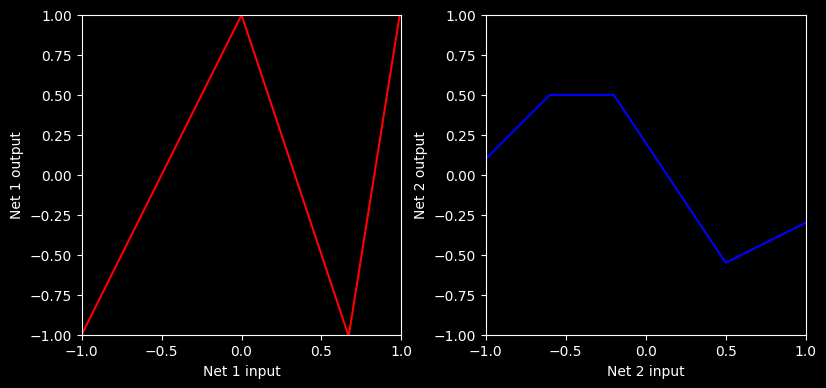

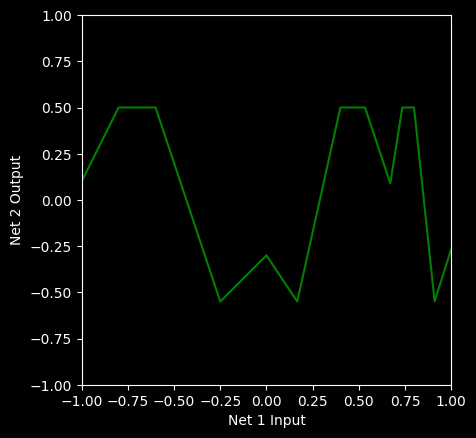

In [29]:
net1_out = shallow_1_1_3(x, ReLU, n1_phi_0, n1_phi_1, n1_phi_2, n1_phi_3, n1_theta_10, n1_theta_11, n1_theta_20, n1_theta_21, n1_theta_30, n1_theta_31)
net12_out = shallow_1_1_3(net1_out, ReLU, n2_phi_0, n2_phi_1, n2_phi_2, n2_phi_3, n2_theta_10, n2_theta_11, n2_theta_20, n2_theta_21, n2_theta_30, n2_theta_31)

# Plot all three graphs
plot_neural_two_components(x, net1_out, net2_out, net12_out)

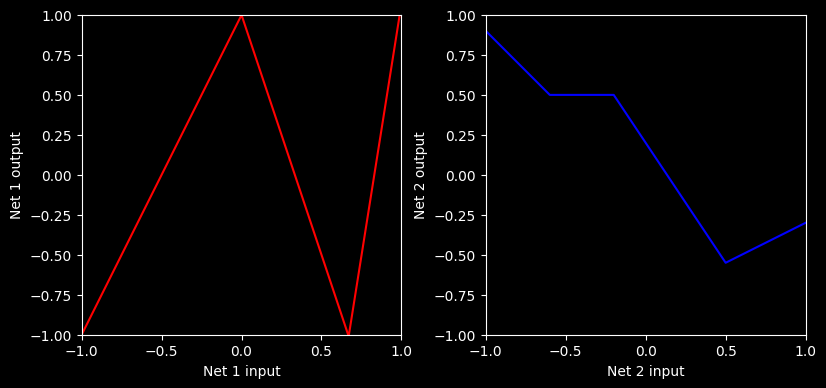

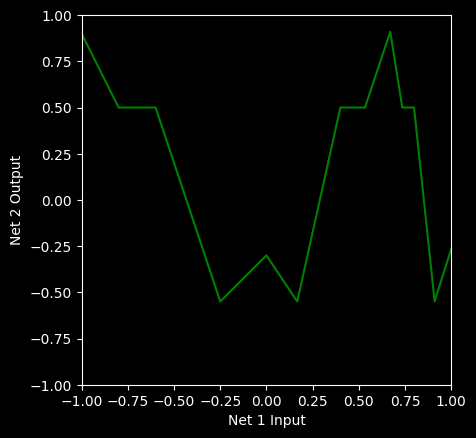

In [24]:
# Now we'll change things a up a bit.  What happens if we change the second network? (note the *-1 change)
net1_out = shallow_1_1_3(x, ReLU, n1_phi_0, n1_phi_1, n1_phi_2, n1_phi_3, n1_theta_10, n1_theta_11, n1_theta_20, n1_theta_21, n1_theta_30, n1_theta_31)
net2_out = shallow_1_1_3(x, ReLU, n2_phi_0, n2_phi_1*-1, n2_phi_2, n2_phi_3, n2_theta_10, n2_theta_11, n2_theta_20, n2_theta_21, n2_theta_30, n2_theta_31)
# plot_neural_two_components(x, net1_out, net2_out)

# When you have a prediction, run this code to see if you were right
net12_out = shallow_1_1_3(net1_out, ReLU, n2_phi_0, n2_phi_1*-1, n2_phi_2, n2_phi_3, n2_theta_10, n2_theta_11, n2_theta_20, n2_theta_21, n2_theta_30, n2_theta_31)
plot_neural_two_components(x, net1_out, net2_out, net12_out)

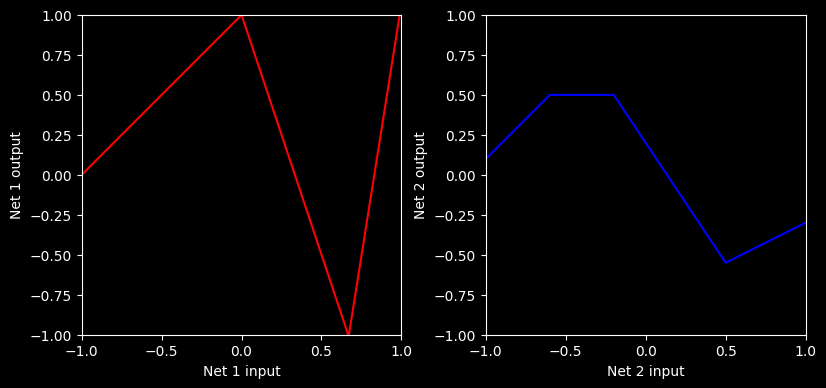

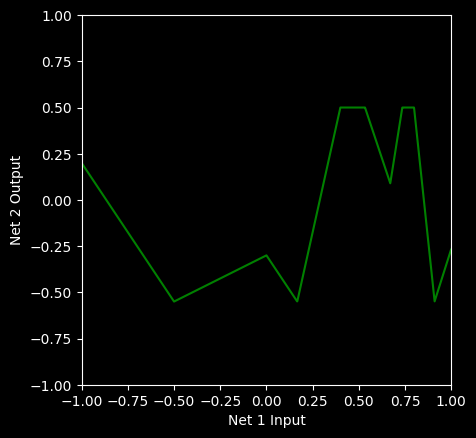

In [25]:
# Let's change things again.  What happens if we change the first network? (note the changes)
net1_out = shallow_1_1_3(x, ReLU, n1_phi_0, n1_phi_1*0.5, n1_phi_2, n1_phi_3, n1_theta_10, n1_theta_11, n1_theta_20, n1_theta_21, n1_theta_30, n1_theta_31)
net2_out = shallow_1_1_3(x, ReLU, n2_phi_0, n2_phi_1, n2_phi_2, n2_phi_3, n2_theta_10, n2_theta_11, n2_theta_20, n2_theta_21, n2_theta_30, n2_theta_31)
# plot_neural_two_components(x, net1_out, net2_out)
# When you have a prediction, run this code to see if you were right
net12_out = shallow_1_1_3(net1_out, ReLU, n2_phi_0, n2_phi_1, n2_phi_2, n2_phi_3, n2_theta_10, n2_theta_11, n2_theta_20, n2_theta_21, n2_theta_30, n2_theta_31)
plot_neural_two_components(x, net1_out, net2_out, net12_out)

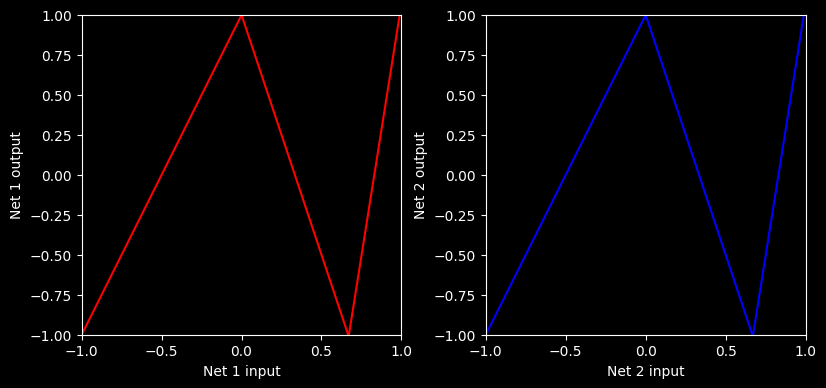

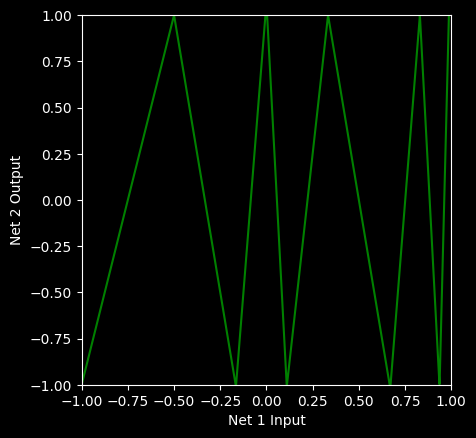

In [26]:
# Let's change things again.  What happens if the first network and second networks are the same?
net1_out = shallow_1_1_3(x, ReLU, n1_phi_0, n1_phi_1, n1_phi_2, n1_phi_3, n1_theta_10, n1_theta_11, n1_theta_20, n1_theta_21, n1_theta_30, n1_theta_31)
net2_out_new = shallow_1_1_3(x, ReLU, n1_phi_0, n1_phi_1, n1_phi_2, n1_phi_3, n1_theta_10, n1_theta_11, n1_theta_20, n1_theta_21, n1_theta_30, n1_theta_31)
# plot_neural_two_components(x, net1_out, net2_out_new)
     
# When you have a prediction, run this code to see if you were right
net12_out = shallow_1_1_3(net1_out, ReLU, n1_phi_0, n1_phi_1, n1_phi_2, n1_phi_3, n1_theta_10, n1_theta_11, n1_theta_20, n1_theta_21, n1_theta_30, n1_theta_31)
plot_neural_two_components(x, net1_out, net2_out_new, net12_out)
     

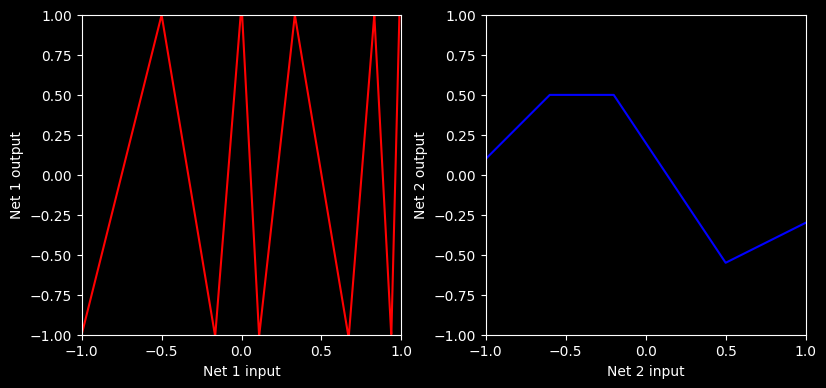

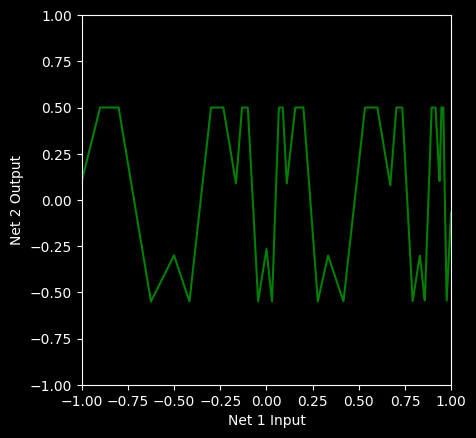

In [27]:
net123_out = shallow_1_1_3(net12_out, ReLU, n2_phi_0, n2_phi_1, n2_phi_2, n2_phi_3, n2_theta_10, n2_theta_11, n2_theta_20, n2_theta_21, n2_theta_30, n2_theta_31)
plot_neural_two_components(x, net12_out, net2_out, net123_out)

Composing neural networks with a 2D input.

a) The first network has three hidden units and takes two inputs $x_1$ and $x_2$ and returns
a scalar output $y$. This is passed into a second network with two hidden units to
produce $y'$.

b) The first network produces a function consisting of seven linear
regions, one of which is flat. 

<img src="assets/Chap04/DeepTwoLayer2D.svg" style="filter: invert(1);" width="100%">


c) The second network defines a function comprising
two linear regions in $y \in [-1, 1]$. 

d) When these networks are composed, each of the six non-flat regions from the first network is divided into two new regions by the second network to create a total of 13 linear regions.


## From shallow to deep networks

In the previous example, the output of the first network $$y= ϕ_0 + ϕ_1h_1 + ϕ_2h_2 + ϕ_3h_3$$ is a linear combination of the activations at the hidden units. 

The first operations of the second network
$$θ'_{10} + θ'_{11}y, θ'_{20} + θ'_{21}y, \text{and} θ'_{30} + θ'_{31}y$$ are linear in the output of the first network. 

Applying one linear function to another yields another linear function. Substituting the expression for $y$ into equation for $h_i$

\begin{eqnarray}\label{eq:dnn_deep_linear}
 h'_{1} &=\quad \mbox{a}[\theta'_{10} + \theta'_{11}y] &=\quad \mbox{a}[\theta'_{10} + \theta'_{11}\phi_{0}+\theta'_{11}\phi_{1}h_{1}+\theta'_{11}\phi_{2}h_{2}+\theta'_{11}\phi_{3}h_{3}] \nonumber \\
 h'_{2} &= \quad\mbox{a}[\theta'_{20} + \theta'_{21}y] &=\quad \mbox{a}[\theta'_{20} + \theta'_{21}\phi_{0}+\theta'_{21}\phi_{1}h_{1}+\theta'_{21}\phi_{2}h_{2}+\theta'_{21}\phi_{3}h_{3}] \nonumber \\
 h'_{3} &=\quad \mbox{a}[\theta'_{30} + \theta'_{31}y] &=\quad \mbox{a}[\theta'_{30} + \theta'_{31}\phi_{0}+\theta'_{31}\phi_{1}h_{1}+\theta'_{31}\phi_{2}h_{2}+\theta'_{31}\phi_{3}h_{3}],
 \end{eqnarray}

which we can rewrite as:

\begin{eqnarray}\label{eq:dnn_three_layer_middle}
 h'_{1} &=& \mbox{a}[\psi_{10} + \psi_{11}h_{1}+ \psi_{12}h_{2}+ \psi_{13}h_{3}] \nonumber \\
 h'_{2} &=& \mbox{a}[\psi_{20} + \psi_{21}h_{1}+ \psi_{22}h_{2}+ \psi_{23}h_{3}] \nonumber \\
 h'_{3} &=& \mbox{a}[\psi_{30} + \psi_{31}h_{1}+ \psi_{32}h_{2}+ \psi_{33}h_{3}],
 \end{eqnarray}

where $\psi_{10} = θ'_{10} + θ'_{11}\phi_0, \psi_{11} = θ′_{11}\phi_1,\psi_{12} = θ'_{11}\phi_2$ and so on. The result is a network with two hidden layers, each containing three hidden units and one input and  one output.


<img src="assets/Chap04/DeepTwoLayer.svg" style="filter: invert(1);" width="100%">


It follows that a network with two layers can represent the family of functions created by passing the output of one single-layer network into another. 

In fact, it represents a broader family because in equation 4.6, the nine slope parameters $\psi_{11},\psi_{21},...,\psi_{33}$ can
take arbitrary values, whereas, in equation 4.5, these parameters are constrained to be
the outer product $[\theta'_{11},\theta'_{21},\theta'_{31}]^T$ [$\phi_1,\phi_2,\phi_3$].



<!-- ## Take away conclusion

With very few parameters, we can make A LOT of linear regions, but they depend on one another in complex ways that quickly become too difficult to understand intuitively. -->